<a href="https://colab.research.google.com/github/MariyaAlshamrani/Bookstore/blob/main/DataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!apt-get update -y
!apt-get install -y chromium-chromedriver
!pip install -q selenium pandas openpyxl


Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
chromium-chromedriver is already the newest version (1:85.0.4183.83-0ubuntu2.22.04.1).
0 upgra

In [25]:
!pip install google-search-results

In [26]:
from serpapi import GoogleSearch
import pandas as pd
import time

api_key = "5850471025406a1e001ebc5f00fbcabab71c71c24475be4494f41834b5da58b4"

queries = [
    # Makkah
    "Hotels in Makkah",
    "Hotels near Masjid al Haram",
    "Hotels in Ajyad Makkah",
    "Hotels in Aziziyah Makkah",
    "Hotels in Al Misfalah Makkah",
    "Hotels in Al Shubaikah Makkah",
    "Hotels in Al Naseem Makkah",
    "Hotels in Kudai Makkah",
    "Hotels in Jarwal Makkah",

    # Madinah
    "Hotels in Madinah",
    "Hotels near Al Masjid an Nabawi",
    "Hotels in Central Madinah",
    "Hotels in Al Haram Madinah",
    "Hotels in Quba Madinah",
    "Hotels in Al Azhari Madinah",
    "Hotels in Al Aridh Madinah",
    "Hotels in Bani Khidrah Madinah"
]

date_ranges = [
    ("2026-02-15", "2026-02-20"),
    ("2026-03-10", "2026-03-15"),
    ("2026-03-20", "2026-03-25"),
    ("2026-05-20", "2026-05-25"),
    ("2026-06-10", "2026-06-15"),
    ("2026-07-01", "2026-07-06")
]

all_hotels = []

for checkin, checkout in date_ranges:
    for q in queries:
        for start in [0, 20, 40, 60, 80]:

            params = {
                "engine": "google_hotels",
                "q": q,
                "check_in_date": checkin,
                "check_out_date": checkout,
                "adults": 2,
                "currency": "SAR",
                "gl": "sa",
                "hl": "ar",
                "start": start,
                "api_key": api_key
            }

            search = GoogleSearch(params)
            results = search.get_dict()

            for h in results.get("properties", []):


                if checkin.startswith("2026-03"):
                    season_type = "Ramadan Season"
                    context_text = "High spiritual tourism season during Ramadan"
                elif checkin.startswith("2026-06"):
                    season_type = "Hajj Peak"
                    context_text = "Peak pilgrimage demand period"
                elif checkin.startswith("2026-05"):
                    season_type = "Pre-Hajj"
                    context_text = "Pre-Hajj booking increase period"
                else:
                    season_type = "Regular Umrah"
                    context_text = "Regular travel season with moderate hotel demand"

                address = h.get("address")
                if not address:
                    gps = h.get("gps_coordinates", {})
                    lat = gps.get("latitude")
                    lng = gps.get("longitude")
                    if lat and lng:
                        address = f"Lat: {lat}, Lng: {lng}"
                    else:
                        address = None


                city = "Madinah" if "Madinah" in q else "Makkah"

                all_hotels.append({
                    "Hotel Name": h.get("name"),
                    "Price (SAR)": h.get("rate_per_night", {}).get("lowest"),
                    "Rating": h.get("overall_rating"),
                    "Reviews": h.get("reviews"),
                    "Address": address,
                    "City": city,
                    "Check-in": checkin,
                    "Check-out": checkout,
                    "Search Area": q,
                    "Season_Type": season_type,
                    "Religious_Context": context_text
                })

            time.sleep(1)

df_final = pd.DataFrame(all_hotels)

df_final = df_final.drop_duplicates(
    subset=["Hotel Name", "Address", "Check-in"]
).reset_index(drop=True)

print("Total rows collected:", len(df_final))

df_final.to_csv("makkah_madinah_hajj_umrah_2026_with_unstructured.csv", index=False)

df_final.head()


Total rows collected: 1129


,Hotel Name,Price (SAR),Rating,Reviews,Address,City,Check-in,Check-out,Search Area,Season_Type,Religious_Context
0,فندق برج الهاشمية,‏١٦٩ ر.س.‏,3.6,398.0,"Lat: 21.4094637, Lng: 39.802396699999996",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan
1,فندق ميلينيوم مكة النسيم,‏٩٢٥ ر.س.‏,4.3,13433.0,"Lat: 21.380888499999998, Lng: 39.8720317",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan
2,فندق نوفوتيل ذاخر مكة,‏٩٠٦ ر.س.‏,4.2,8334.0,"Lat: 21.445215500000003, Lng: 39.8343673",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan
3,فندق سجى مكة,‏١٬١٣٥ ر.س.‏,4.2,605.0,"Lat: 21.403581300000003, Lng: 39.8261687",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan
4,فندق سنود الدانه | Snood Al-Dana Hotel,‏٣٢٨ ر.س.‏,3.9,943.0,"Lat: 21.3997575, Lng: 39.88258090000001",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan


In [27]:
from serpapi import GoogleSearch
import pandas as pd
import time

api_key = "5850471025406a1e001ebc5f00fbcabab71c71c24475be4494f41834b5da58b4"

queries = [
    "Hotels in Taif",
    "Hotels in Taif for Hajj visitors",
    "Hotels in Taif near Miqat",
    "Umrah visitor hotels in Taif",
    "Budget hotels in Taif for pilgrims",
    "Luxury hotels in Taif during Hajj season",
    "Hotels in Taif near Al Sail Al Kabir Miqat"
]

date_ranges = [
    ("2026-02-15", "2026-02-20"),
    ("2026-03-10", "2026-03-15"),
    ("2026-03-20", "2026-03-25"),
    ("2026-05-20", "2026-05-25"),
    ("2026-06-10", "2026-06-15"),
    ("2026-07-01", "2026-07-06")
]

all_hotels = []

for checkin, checkout in date_ranges:
    for q in queries:
        for start in [0, 20, 40]:

            params = {
                "engine": "google_hotels",
                "q": q,
                "check_in_date": checkin,
                "check_out_date": checkout,
                "adults": 2,
                "currency": "SAR",
                "gl": "sa",
                "hl": "ar",
                "start": start,
                "api_key": api_key
            }

            search = GoogleSearch(params)
            results = search.get_dict()

            for h in results.get("properties", []):


                if checkin.startswith("2026-03"):
                    season_type = "Ramadan Season"
                    context_text = "Ramadan spiritual tourism season affecting Taif hotels"
                elif checkin.startswith("2026-06"):
                    season_type = "Hajj Peak"
                    context_text = "Hajj season overflow demand with pilgrims staying in Taif"
                elif checkin.startswith("2026-05"):
                    season_type = "Pre-Hajj"
                    context_text = "Pre-Hajj increasing accommodation demand in Taif"
                else:
                    season_type = "Regular Umrah"
                    context_text = "Regular Umrah related travel near Makkah region"

                address = h.get("address")
                if not address:
                    gps = h.get("gps_coordinates", {})
                    lat = gps.get("latitude")
                    lng = gps.get("longitude")
                    if lat and lng:
                        address = f"Lat: {lat}, Lng: {lng}"
                    else:
                        address = None

                all_hotels.append({
                    "Hotel Name": h.get("name"),
                    "City": "Taif",
                    "Price (SAR)": h.get("rate_per_night", {}).get("lowest"),
                    "Rating": h.get("overall_rating"),
                    "Reviews": h.get("reviews"),
                    "Address": address,
                    "Check-in": checkin,
                    "Check-out": checkout,
                    "Search Area": q,
                    "Season_Type": season_type,
                    "Religious_Context": context_text
                })

            time.sleep(1)

df_taif = pd.DataFrame(all_hotels)

df_taif = df_taif.drop_duplicates(
    subset=["Hotel Name", "Address", "Check-in"]
).reset_index(drop=True)

print("Total Taif rows:", len(df_taif))

df_taif.to_csv("taif_hajj_umrah_2026.csv", index=False)

df_taif.head()

Total Taif rows: 328


,Hotel Name,City,Price (SAR),Rating,Reviews,Address,Check-in,Check-out,Search Area,Season_Type,Religious_Context
0,الديوان النجدي للشقق المخدومة اقتصادي - One-Be...,Taif,‏١٧٩ ر.س.‏,NaN,NaN,"Lat: 21.484140396118164, Lng: 40.48775863647461",2026-03-10,2026-03-15,Hotels in Taif,Ramadan Season,Ramadan spiritual tourism season affecting Tai...
1,ناضرة الوسام للشقق المخدومة - Two-Bedroom Apar...,Taif,‏١٦٢ ر.س.‏,2.800000,7.0,"Lat: 21.22488021850586, Lng: 40.38262176513672",2026-03-10,2026-03-15,Hotels in Taif,Ramadan Season,Ramadan spiritual tourism season affecting Tai...
2,فخامة الديار للشقق المخدومة Fakhamat Aldyar Fo...,Taif,‏١٩٣ ر.س.‏,4.013043,23.0,"Lat: 21.319499969482422, Lng: 40.428550720214844",2026-03-10,2026-03-15,Hotels in Taif,Ramadan Season,Ramadan spiritual tourism season affecting Tai...
3,شاليهات تولين - Two-Bedroom Apartment,Taif,‏٣٠٠ ر.س.‏,NaN,NaN,"Lat: 21.49803924560547, Lng: 40.4958610534668",2026-03-10,2026-03-15,Hotels in Taif,Ramadan Season,Ramadan spiritual tourism season affecting Tai...
4,شاليهات دشيل لبيوت العطلات الاقتصادية - Two-Be...,Taif,‏٤٤٧ ر.س.‏,4.950000,8.0,"Lat: 21.230449676513672, Lng: 40.38397979736328",2026-03-10,2026-03-15,Hotels in Taif,Ramadan Season,Ramadan spiritual tourism season affecting Tai...


In [28]:
import pandas as pd

df_main = pd.read_csv("makkah_madinah_hajj_umrah_2026_with_unstructured.csv")
df_taif = pd.read_csv("taif_hajj_umrah_2026.csv")

print("Rows before merge:")
print("Main file:", len(df_main))
print("Taif file:", len(df_taif))

df_main.columns = df_main.columns.str.strip()
df_taif.columns = df_taif.columns.str.strip()

df_combined = pd.concat([df_main, df_taif], ignore_index=True, sort=False)

df_combined = df_combined.drop_duplicates(
    subset=["Hotel Name", "Address", "Check-in"]
).reset_index(drop=True)

print("Final merged rows:", len(df_combined))

df_combined.to_csv("FINAL_HAJJ_UMRAH_ALL_CITIES_2026.csv", index=False)

df_combined.head()


Rows before merge:
Main file: 1129
Taif file: 328
Final merged rows: 1457


,Hotel Name,Price (SAR),Rating,Reviews,Address,City,Check-in,Check-out,Search Area,Season_Type,Religious_Context
0,فندق برج الهاشمية,‏١٦٩ ر.س.‏,3.6,398.0,"Lat: 21.4094637, Lng: 39.802396699999996",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan
1,فندق ميلينيوم مكة النسيم,‏٩٢٥ ر.س.‏,4.3,13433.0,"Lat: 21.380888499999998, Lng: 39.8720317",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan
2,فندق نوفوتيل ذاخر مكة,‏٩٠٦ ر.س.‏,4.2,8334.0,"Lat: 21.445215500000003, Lng: 39.8343673",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan
3,فندق سجى مكة,‏١٬١٣٥ ر.س.‏,4.2,605.0,"Lat: 21.403581300000003, Lng: 39.8261687",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan
4,فندق سنود الدانه | Snood Al-Dana Hotel,‏٣٢٨ ر.س.‏,3.9,943.0,"Lat: 21.3997575, Lng: 39.88258090000001",Makkah,2026-03-10,2026-03-15,Hotels in Makkah,Ramadan Season,High spiritual tourism season during Ramadan


In [29]:
import numpy as np
#create a copy of the data
df_raw = pd.read_csv("FINAL_HAJJ_UMRAH_ALL_CITIES_2026.csv")

df = df_raw.copy()

In [30]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1457 entries, 0 to 1456
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Hotel Name         1457 non-null   object 
 1   Price (SAR)        815 non-null    object 
 2   Rating             1387 non-null   float64
 3   Reviews            1387 non-null   float64
 4   Address            1457 non-null   object 
 5   City               1457 non-null   object 
 6   Check-in           1457 non-null   object 
 7   Check-out          1457 non-null   object 
 8   Search Area        1457 non-null   object 
 9   Season_Type        1457 non-null   object 
 10  Religious_Context  1457 non-null   object 
dtypes: float64(2), object(9)
memory usage: 125.3+ KB


,Rating,Reviews
count,1387.000000,1387.000000
mean,4.098900,3673.620043
std,0.474159,10426.445785
min,2.000000,1.000000
25%,3.800000,157.000000
50%,4.100000,590.000000
75%,4.400000,1956.000000
max,5.000000,117053.000000


In [31]:
# Calculate missing values percentage
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})

missing_table.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
Price (SAR),642,44.063143
Rating,70,4.804393
Reviews,70,4.804393
Hotel Name,0,0.000000
Address,0,0.000000
City,0,0.000000
Check-in,0,0.000000
Check-out,0,0.000000
Search Area,0,0.000000
Season_Type,0,0.000000


In [32]:
# Remove duplicates based on specific booking details (Address, Check-in, Check-out) rather than just the hotel name
duplicate_count = df.duplicated(subset=['Address', 'Check-in', 'Check-out']).sum()
print(f"Number of duplicates found: {duplicate_count}")

df.drop_duplicates(subset=['Address', 'Check-in', 'Check-out'], inplace=True)
df.drop_duplicates(inplace=True)

Number of duplicates found: 0


In [33]:
import re
# Clean the Price column: convert Arabic numerals to English and extract only digits

def arabic_to_english_number(text):
    arabic_numbers = "٠١٢٣٤٥٦٧٨٩"
    english_numbers = "0123456789"
    translator = str.maketrans(arabic_numbers, english_numbers)
    return text.translate(translator)

def clean_price(value):
    if pd.isna(value):
        return None
    value = str(value)
    value = arabic_to_english_number(value)
    value = re.sub(r"[^\d]", "", value)
    if value == "":
        return None
    return float(value)

df["Price (SAR)"] = df["Price (SAR)"].apply(clean_price)

print(df["Price (SAR)"])

0        169.0
1        925.0
2        906.0
3       1135.0
4        328.0
         ...  
1452       NaN
1453       NaN
1454       NaN
1455       NaN
1456    1137.0
Name: Price (SAR), Length: 1457, dtype: float64


In [34]:
# Impute missing values:
# - Median for Price
# - Mean for Rating
# - 0 for Reviews

df["Price (SAR)"] = df["Price (SAR)"].fillna(df["Price (SAR)"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].mean()).round(1)
df["Reviews"] = df["Reviews"].fillna(0)

print(df.isnull().sum())

Hotel Name           0
Price (SAR)          0
Rating               0
Reviews              0
Address              0
City                 0
Check-in             0
Check-out            0
Search Area          0
Season_Type          0
Religious_Context    0
dtype: int64


In [35]:
# Extract Latitude and Longitude from the Address string

df[["Latitude", "Longitude"]] = df["Address"].str.extract(r"Lat:\s*(-?[\d\.]+),\s*Lng:\s*(-?[\d\.]+)")

df["Latitude"] = pd.to_numeric(df["Latitude"])
df["Longitude"] = pd.to_numeric(df["Longitude"])

print(df[["Address", "Latitude", "Longitude"]].head())

                                    Address   Latitude  Longitude
0  Lat: 21.4094637, Lng: 39.802396699999996  21.409464  39.802397
1  Lat: 21.380888499999998, Lng: 39.8720317  21.380889  39.872032
2  Lat: 21.445215500000003, Lng: 39.8343673  21.445216  39.834367
3  Lat: 21.403581300000003, Lng: 39.8261687  21.403581  39.826169
4   Lat: 21.3997575, Lng: 39.88258090000001  21.399757  39.882581


In [36]:
# Standardize date columns to datetime objects
df["Check-in"] = pd.to_datetime(df["Check-in"])
df["Check-out"] = pd.to_datetime(df["Check-out"])
print(df[["Check-in", "Check-out"]])

       Check-in  Check-out
0    2026-03-10 2026-03-15
1    2026-03-10 2026-03-15
2    2026-03-10 2026-03-15
3    2026-03-10 2026-03-15
4    2026-03-10 2026-03-15
...         ...        ...
1452 2026-07-01 2026-07-06
1453 2026-07-01 2026-07-06
1454 2026-07-01 2026-07-06
1455 2026-07-01 2026-07-06
1456 2026-07-01 2026-07-06

[1457 rows x 2 columns]


In [37]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1457 entries, 0 to 1456
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Hotel Name         1457 non-null   object        
 1   Price (SAR)        1457 non-null   float64       
 2   Rating             1457 non-null   float64       
 3   Reviews            1457 non-null   float64       
 4   Address            1457 non-null   object        
 5   City               1457 non-null   object        
 6   Check-in           1457 non-null   datetime64[ns]
 7   Check-out          1457 non-null   datetime64[ns]
 8   Search Area        1457 non-null   object        
 9   Season_Type        1457 non-null   object        
 10  Religious_Context  1457 non-null   object        
 11  Latitude           1457 non-null   float64       
 12  Longitude          1457 non-null   float64       
dtypes: datetime64[ns](2), float64(5), object(6)
memory usage: 148.1

,0
Hotel Name,0
Price (SAR),0
Rating,0
Reviews,0
Address,0
City,0
Check-in,0
Check-out,0
Search Area,0
Season_Type,0


In [38]:
df.to_csv("CLEANED_HAJJ_UMRAH.csv", index=False)

In [39]:
# إنشاء مدة الإقامة
df["Stay_Duration"] = (df["Check-out"] - df["Check-in"]).dt.days

# إنشاء فئة سعرية
df["Price_Category"] = pd.cut(
    df["Price (SAR)"],
    bins=[0, 300, 800, 1500, 10000],
    labels=["Budget", "Mid-Range", "Premium", "Luxury"]
)

In [40]:
# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=["City", "Season_Type", "Price_Category"],
    drop_first=False
)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = ["Price (SAR)", "Rating", "Reviews", "Stay_Duration"]

df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

In [42]:
df_encoded.to_csv("PROCESSED_HAJJ_UMRAH_2026.csv", index=False)

# **EDA**

In [43]:
import numpy as np
import pandas as pd
#create a copy of the data
df_raw = pd.read_csv("PROCESSED_HAJJ_UMRAH_2026.csv")

df = df_raw.copy()


In [44]:
df["Price (SAR)"] = pd.to_numeric(df["Price (SAR)"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")


In [45]:
df[["Price (SAR)", "Rating"]].describe()
# Generated descriptive statistics for Price and Rating.
# The mean is approximately 0 and the standard deviation is close to 1,
# confirming successful standardization.
# The maximum price value is significantly higher than the rest,
# indicating the presence of an extreme price outlier.

,Price (SAR),Rating
count,1.457000e+03,1.457000e+03
mean,2.926051e-17,-4.291542e-16
std,1.000343e+00,1.000343e+00
min,-2.741480e-01,-4.535208e+00
25%,-1.007762e-01,-6.459803e-01
50%,-8.325125e-02,2.224450e-03
75%,-5.696382e-02,6.504292e-01
max,3.657456e+01,1.946839e+00


In [46]:
df[["City_Makkah","City_Madinah","City_Taif"]].sum()
#Makkah contains the highest number of hotels, followed by Madinah, while Taif has the lowest number.
 #This suggests that hotel supply is concentrated in Makkah, likely due to higher demand.

,0
City_Makkah,765
City_Madinah,364
City_Taif,328


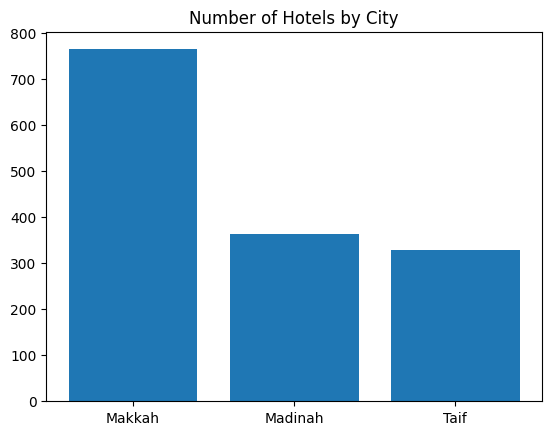

In [47]:
plt.figure()
city_counts = df[["City_Makkah","City_Madinah","City_Taif"]].sum()
plt.bar(["Makkah","Madinah","Taif"], city_counts)
plt.title("Number of Hotels by City")
plt.show()
#The visualization clearly shows that Makkah dominates in hotel availability,
#indicating it is the primary destination among the three cities.

In [48]:
df[[
    "Season_Type_Hajj Peak",
    "Season_Type_Pre-Hajj",
    "Season_Type_Ramadan Season",
    "Season_Type_Regular Umrah"
]].sum()
#Ramadan season has the highest number of hotels, while other seasons are relatively similar in distribution.
#This suggests that Ramadan is a peak operational period.


,0
Season_Type_Hajj Peak,289
Season_Type_Pre-Hajj,292
Season_Type_Ramadan Season,588
Season_Type_Regular Umrah,288


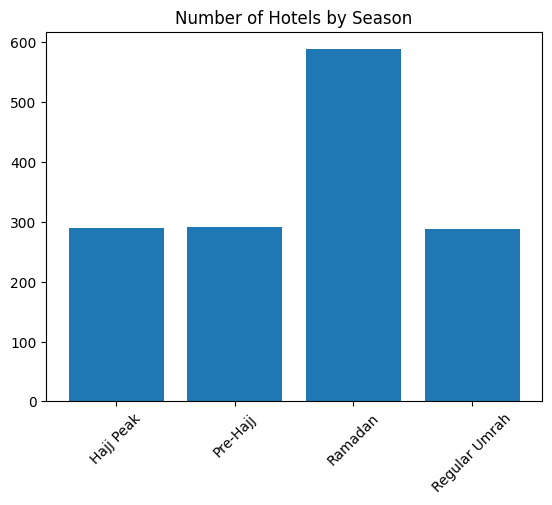

In [49]:
plt.figure()
season_counts = df[
    ["Season_Type_Hajj Peak",
     "Season_Type_Pre-Hajj",
     "Season_Type_Ramadan Season",
     "Season_Type_Regular Umrah"]
].sum()

plt.bar(["Hajj Peak","Pre-Hajj","Ramadan","Regular Umrah"], season_counts)
plt.xticks(rotation=45)
plt.title("Number of Hotels by Season")
plt.show()
#The bar chart confirms that hotel availability increases during Ramadan,
#indicating higher demand compared to other seasons.

In [50]:
df[["Price (SAR)", "Rating"]].corr()
#There is almost no correlation between price and rating,
#indicating that higher-priced hotels do not necessarily receive better ratings.

,Price (SAR),Rating
Price (SAR),1.000000,0.029602
Rating,0.029602,1.000000


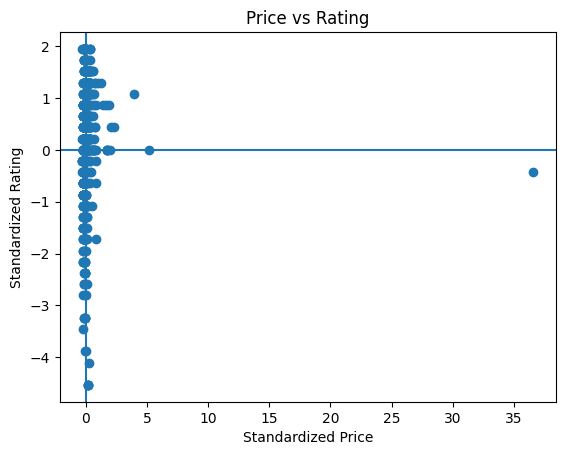

In [51]:
plt.figure()
plt.scatter(df["Price (SAR)"], df["Rating"])
plt.title("Price vs Rating")
plt.xlabel("Standardized Price")
plt.ylabel("Standardized Rating")
plt.axhline(0)
plt.axvline(0)
plt.show()
#The scatter plot shows no clear linear relationship between price and rating.
#Most data points cluster around average values, with a noticeable outlier at a very high price.


 # Secondary EDA

This section performs deeper analysis of the dataset and explores additional relationships between variables.

In [52]:
import matplotlib.pyplot as plt

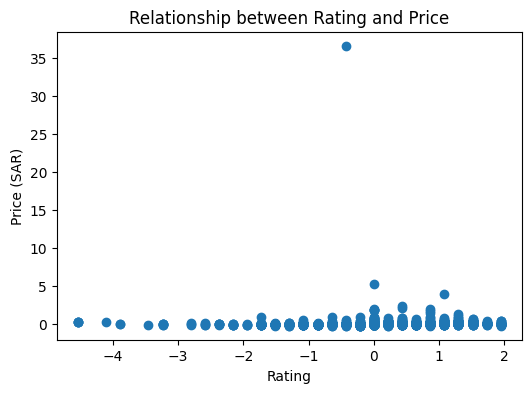

In [53]:
# Relationship between Rating and Price

plt.figure(figsize=(6,4))
plt.scatter(df["Rating"], df["Price (SAR)"])
plt.xlabel("Rating")
plt.ylabel("Price (SAR)")
plt.title("Relationship between Rating and Price")
plt.show()

In [56]:
print(df.columns)

Index(['Hotel Name', 'Price (SAR)', 'Rating', 'Reviews', 'Address', 'Check-in',
       'Check-out', 'Search Area', 'Religious_Context', 'Latitude',
       'Longitude', 'Stay_Duration', 'City_Madinah', 'City_Makkah',
       'City_Taif', 'Season_Type_Hajj Peak', 'Season_Type_Pre-Hajj',
       'Season_Type_Ramadan Season', 'Season_Type_Regular Umrah',
       'Price_Category_Budget', 'Price_Category_Mid-Range',
       'Price_Category_Premium', 'Price_Category_Luxury'],
      dtype='object')


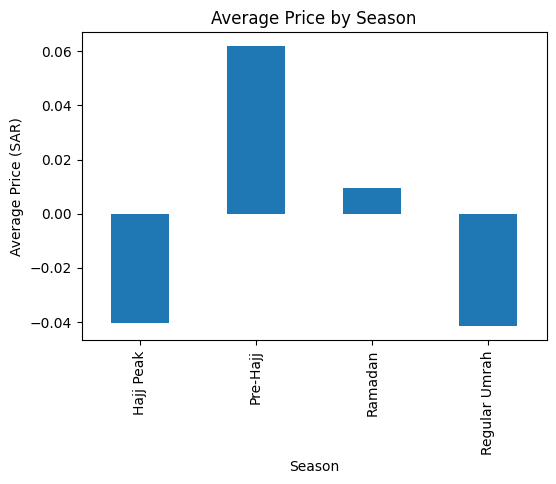

In [57]:
# Average price by season

season_price = {
    "Hajj Peak": df[df["Season_Type_Hajj Peak"] == 1]["Price (SAR)"].mean(),
    "Pre-Hajj": df[df["Season_Type_Pre-Hajj"] == 1]["Price (SAR)"].mean(),
    "Ramadan": df[df["Season_Type_Ramadan Season"] == 1]["Price (SAR)"].mean(),
    "Regular Umrah": df[df["Season_Type_Regular Umrah"] == 1]["Price (SAR)"].mean()
}

season_price = pd.Series(season_price)

plt.figure(figsize=(6,4))
season_price.plot(kind="bar")
plt.title("Average Price by Season")
plt.xlabel("Season")
plt.ylabel("Average Price (SAR)")
plt.show()

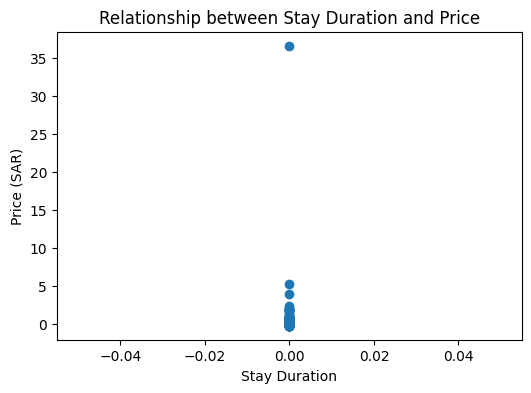

In [58]:
# Relationship between Stay Duration and Price
plt.figure(figsize=(6,4))
plt.scatter(df["Stay_Duration"], df["Price (SAR)"])
plt.xlabel("Stay Duration")
plt.ylabel("Price (SAR)")
plt.title("Relationship between Stay Duration and Price")
plt.show()

# Insight:
# This plot checks whether longer stays tend to have higher prices.

In [59]:
summary = pd.DataFrame({
    "City": ["Makkah", "Madinah", "Taif"],
    "Avg_Price": [
        df[df["City_Makkah"] == 1]["Price (SAR)"].mean(),
        df[df["City_Madinah"] == 1]["Price (SAR)"].mean(),
        df[df["City_Taif"] == 1]["Price (SAR)"].mean()
    ],
    "Avg_Rating": [
        df[df["City_Makkah"] == 1]["Rating"].mean(),
        df[df["City_Madinah"] == 1]["Rating"].mean(),
        df[df["City_Taif"] == 1]["Rating"].mean()
    ]
})

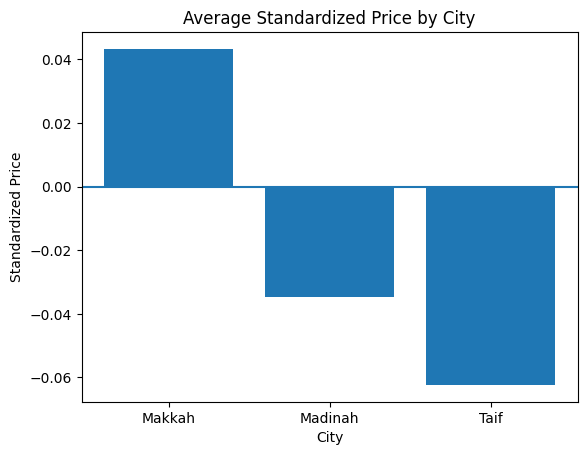

In [60]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(summary["City"], summary["Avg_Price"])
plt.title("Average Standardized Price by City")
plt.xlabel("City")
plt.ylabel("Standardized Price")
plt.axhline(0)
plt.show()
#Makkah has the highest average standardized price, while Taif has the lowest.
#This indicates that hotels in Makkah tend to be more expensive on average.

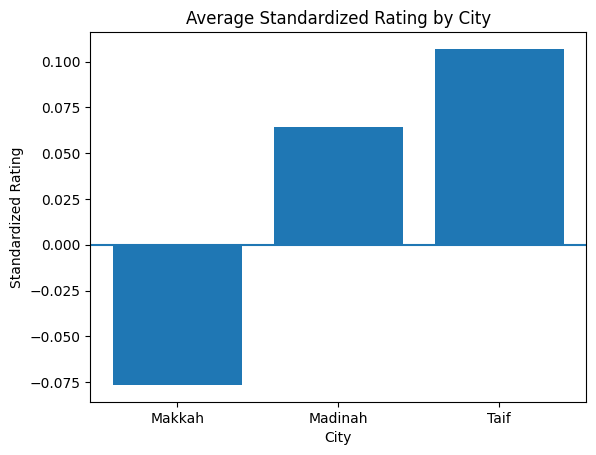

In [61]:
plt.figure()
plt.bar(summary["City"], summary["Avg_Rating"])
plt.title("Average Standardized Rating by City")
plt.xlabel("City")
plt.ylabel("Standardized Rating")
plt.axhline(0)
plt.show()
#Madinah has the highest average rating
# followed by Taif, while Makkah has the lowest average rating among the three cities.

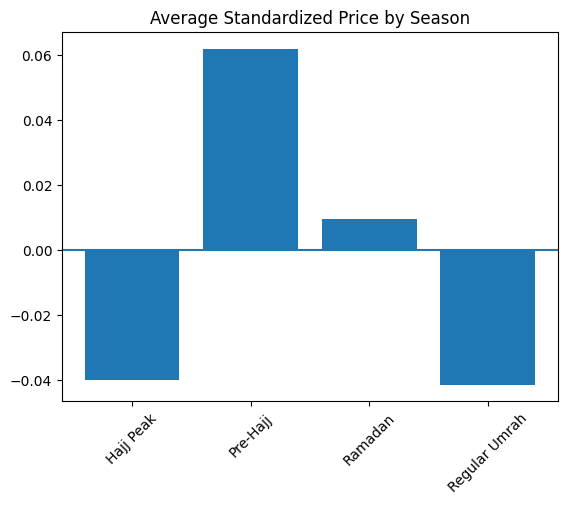

In [62]:
season_price = pd.DataFrame({
    "Season": ["Hajj Peak", "Pre-Hajj", "Ramadan", "Regular Umrah"],
    "Avg_Price": [
        df[df["Season_Type_Hajj Peak"] == 1]["Price (SAR)"].mean(),
        df[df["Season_Type_Pre-Hajj"] == 1]["Price (SAR)"].mean(),
        df[df["Season_Type_Ramadan Season"] == 1]["Price (SAR)"].mean(),
        df[df["Season_Type_Regular Umrah"] == 1]["Price (SAR)"].mean()
    ]
})

plt.figure()
plt.bar(season_price["Season"], season_price["Avg_Price"])
plt.title("Average Standardized Price by Season")
plt.xticks(rotation=45)
plt.axhline(0)
plt.show()
# The bar chart shows the average standardized hotel price across different seasons.
# Pre-Hajj has the highest average price, followed by Ramadan.
# Hajj Peak and Regular Umrah show lower average prices.
# This indicates that price increases tend to occur before the peak pilgrimage period.